# Predicting Hospital Inpatient Charges
### New York State SPARCS 2021 | Supervised Machine Learning Pipeline

**Dataset:** 50,000 inpatient discharge records — New York State Department of Health (SPARCS 2021)  
**Target:** `total_charges` — total amount billed per inpatient stay  
**Methods:** Linear Regression, Ridge, Lasso, Decision Tree, Random Forest, XGBoost  
**Best result:** Tuned XGBoost — R² = 0.814, MAE = $18,011, 31% RMSE reduction vs. linear baseline

*Developed as part of BA810 Supervised Machine Learning coursework at Boston University's Questrom School of Business.*

## Business Problem

Hospital inpatient charges in New York State vary dramatically — by more than 10× across facilities for patients with similar diagnoses and clinical profiles. This variability creates operational and financial uncertainty for hospitals, insurers, policymakers, and patients alike.

**The core question this project addresses:** Can patient demographics, clinical characteristics, and hospital-level features predict inpatient charges with sufficient accuracy to be useful for benchmarking, anomaly detection, and financial planning?

We approach this as a supervised regression problem, using a 50,000-record sample from New York State's SPARCS 2021 inpatient discharge census. The target variable — `total_charges` — reflects what hospitals bill per stay. Rather than attempting to isolate causal mechanisms, this analysis builds a data-driven baseline: a model that can estimate expected charges from observable features, enabling stakeholders to identify cases where actual charges deviate significantly from predicted norms.

## Stakeholder Context

Accurate charge prediction has direct operational value across multiple groups:

**Hospitals and Health Systems** can benchmark their actual billing against predicted statewide norms — surfacing facilities whose charges are systematically high or low relative to patient mix and clinical complexity. This supports budgeting, revenue planning, and internal audit processes.

**Insurance Providers** can use charge predictions to calibrate reimbursement rates, flag potential billing anomalies, and support actuarial modeling for rate-setting negotiations.

**Government and Policymakers** gain a tool to monitor regional and demographic pricing disparities — an increasingly important input to healthcare price transparency regulation.

**Patients and Families** benefit indirectly: a more transparent charge environment, enabled by predictive benchmarking, reduces the opacity that currently makes healthcare financial planning difficult.

> **Note on scope:** This model predicts billed charges, not actual costs or payments received. The relationship between charges and reimbursement varies significantly by payer type. Predictions should be interpreted as billing benchmarks, not cost estimates.

## Dataset Overview

**Source:** New York State Department of Health, Hospital Inpatient Discharges (SPARCS De-Identified) — 2021  
**Records:** 50,000 inpatient hospitalizations (sampled from the full statewide census for computational efficiency)  
**Features:** 33 variables across five categories

| Category | Key Fields |
|----------|-----------|
| Hospital & Facility | `hospital_service_area`, `hospital_county`, `facility_name` |
| Patient Demographics | `age_group`, `gender`, `race`, `ethnicity`, `zip_code_3_digits` |
| Visit Characteristics | `length_of_stay`, `type_of_admission`, `patient_disposition`, `emergency_department_indicator` |
| Clinical Classification | `ccsr_diagnosis_code`, `apr_drg_code`, `apr_severity_of_illness_code`, `apr_risk_of_mortality` |
| Target & Financial | `total_charges` (prediction target), `total_costs` (excluded — potential leakage) |

**Data quality notes:**
- `length_of_stay` is stored as a string object due to a `120+` cap on long-stay cases — requires parsing before modeling
- `ccsr_procedure_code` has approx. 13,600 missing values (~27% of records) — patients without a recorded procedure
- Several hospital-level identifier fields contain small numbers of nulls (~119–917 records), handled via imputation
- `total_costs` is excluded from features: it is derived from charges and would constitute target leakage

## Environment Setup & Data Loading

### Data Source

This notebook loads data from the New York State SPARCS 2021 inpatient discharge dataset (50,000-record sample). Two loading options are provided:

**Option 1 (default):** Loads directly from Google Drive via URL — works in Google Colab without any setup.  
**Option 2:** Upload the CSV file manually — use this if running locally or if the Drive link becomes unavailable.

The dataset is publicly available from the [New York State Department of Health SPARCS data portal](https://health.data.ny.gov/Health/Hospital-Inpatient-Discharges-SPARCS-De-Identified/gnzp-ekau).

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import set_config
import os
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from scipy.stats import uniform, loguniform

In [32]:
import os

# ── DATA LOADING ──────────────────────────────────────────────────────────────
# Option 1: Load from Google Drive (default — works in Colab)
DRIVE_URL = 'https://docs.google.com/uc?export=download&id=1XQ1-fFmE1XmRQ1G3f3OPvktl8nXOHW5_'

# Option 2: Local upload — uncomment and set LOCAL_PATH if running locally
# LOCAL_PATH = 'hospital-inpatient-discharges-sparcs-2021-sample.csv'

# ── Load whichever source is available ────────────────────────────────────────
if 'LOCAL_PATH' in dir() and os.path.exists(LOCAL_PATH):
    print("Loading from local file...")
    rawdata = pd.read_csv(LOCAL_PATH, low_memory=False)
else:
    print("Loading from Google Drive URL...")
    rawdata = pd.read_csv(DRIVE_URL, low_memory=False)

rawdata = rawdata.copy()
print(f"Loaded successfully: {rawdata.shape[0]:,} rows, {rawdata.shape[1]} columns")

Loading from Google Drive URL...
Loaded successfully: 50,000 rows, 33 columns


In [33]:
rawdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   hospital_service_area                49881 non-null  object 
 1   hospital_county                      49881 non-null  object 
 2   operating_certificate_number         49846 non-null  float64
 3   permanent_facility_id                49881 non-null  float64
 4   facility_name                        50000 non-null  object 
 5   age_group                            50000 non-null  object 
 6   zip_code_3_digits                    49083 non-null  object 
 7   gender                               50000 non-null  object 
 8   race                                 50000 non-null  object 
 9   ethnicity                            50000 non-null  object 
 10  length_of_stay                       50000 non-null  object 
 11  type_of_admission           

### Initial Data Assessment

The dataset loads cleanly with 50,000 rows and 33 columns. Key observations from `.info()`:

- **Mixed types:** `length_of_stay` is stored as `object` due to the `120+` cap — will be parsed to numeric during preprocessing
- **Missingness:** `ccsr_procedure_code` (~27% null) and `ccsr_procedure_description` (~27% null) reflect patients admitted without a coded procedure, not data entry errors. These are handled with frequency encoding and imputation in the pipeline
- **Excluded columns:** `total_costs`, facility identifiers (`operating_certificate_number`, `permanent_facility_id`), and text description fields are dropped before modeling — either for leakage risk or redundancy with coded equivalents

## Exploratory Data Analysis (EDA)

### What the Data Shows Before Modeling

Before building any models, the data was explored across four dimensions: target distribution, key clinical and operational drivers, payer-type effects, and geographic variation. The findings from this section directly motivated the preprocessing pipeline design.

The most important structural observation: **total inpatient charges are extremely right-skewed**, with a small proportion of cases driving the upper tail. This alone rules out treating charges as a normally distributed target and necessitates log-transformation and Winsorization before modeling.

### Data Cleaning

Several fields are dropped before analysis: `total_costs` (excluded to prevent target leakage, as costs are derived from charges), numeric facility identifiers (redundant given `facility_name` and `hospital_county`), and text description columns that are redundant with their coded equivalents. `length_of_stay` is parsed from string to numeric, with the `120+` cap replaced by the value 120.

In [34]:
rawdata = rawdata.copy()
drop_cols = [
    'facility_name',
    'operating_certificate_number',
    'permanent_facility_id',
    'ccsr_diagnosis_description',
    'ccsr_procedure_description',
    'apr_drg_description',
    'apr_mdc_description',
    'apr_severity_of_illness_description',
    'payment_typology_2',
    'payment_typology_3',
    'total_costs',
    'birth_weight'
]
rawdata = rawdata.drop(columns=[c for c in drop_cols if c in rawdata.columns])

rawdata['total_charges'] = (
    rawdata['total_charges']
    .astype(str)
    .str.strip()
    .str.replace(r'[\$,]', '', regex=True)
)
rawdata['total_charges'] = pd.to_numeric(rawdata['total_charges'], errors='coerce')
rawdata = rawdata[rawdata['total_charges'] > 0]

print(f"\nTotal charges statistics:")
print(rawdata['total_charges'].describe())

rawdata['length_of_stay'] = pd.to_numeric(rawdata['length_of_stay'], errors='coerce')

categorical_cols = [
    'age_group', 'gender', 'race', 'ethnicity',
    'type_of_admission', 'patient_disposition',
    'payment_typology_1',
    'emergency_department_indicator',
    'hospital_service_area', 'hospital_county',
    'zip_code_3_digits', 'discharge_year',
    'ccsr_diagnosis_code', 'ccsr_procedure_code',
    'apr_drg_code', 'apr_mdc_code',
    'apr_severity_of_illness_code',
    'apr_risk_of_mortality',
    'apr_medical_surgical_description'
]

for col in categorical_cols:
    rawdata[col] = rawdata[col].astype("category")

def fill_cat(df, col, new_label):
    df[col] = df[col].astype("category").cat.add_categories(new_label).fillna(new_label)

fill_cat(rawdata, "ccsr_procedure_code", "NO_PROCEDURE")
fill_cat(rawdata, "zip_code_3_digits", "Unknown_ZIP")
fill_cat(rawdata, "hospital_service_area", "Unknown_Area")
fill_cat(rawdata, "hospital_county", "Unknown_County")
fill_cat(rawdata, "apr_risk_of_mortality", "Unknown_Risk")

print(f"\nMissing values after filling:")
print(rawdata.isna().sum().sort_values(ascending=False).head())


Total charges statistics:
count    5.000000e+04
mean     7.354754e+04
std      1.797797e+05
min      1.767100e+02
25%      1.885825e+04
50%      3.837590e+04
75%      7.691233e+04
max      1.793575e+07
Name: total_charges, dtype: float64

Missing values after filling:
length_of_stay           30
hospital_county           0
age_group                 0
zip_code_3_digits         0
hospital_service_area     0
dtype: int64


In [35]:
rawdata['total_charges'] = (
    rawdata['total_charges']
        .astype(str)
        .str.strip()
        .str.replace(r'[\$,]', '', regex=True)
)

rawdata['total_charges'] = pd.to_numeric(rawdata['total_charges'], errors='coerce')
rawdata = rawdata[rawdata['total_charges'] > 0]

### Target Variable Distribution

#### Distribution of Total Charges

Total inpatient charges are heavily right-skewed: the raw distribution shows nearly all observations compressed near zero with a long upper tail driven by a small number of extreme cases. On the original scale, the distribution is nearly unreadable for modeling purposes.

Applying a log transformation (`log(charges + 1)`) produces an approximately normal distribution centered around the $40,000–$60,000 range on the original scale. This transformation is a standard and well-motivated step for financial targets — it stabilizes variance, reduces the influence of extreme values on model training, and allows regression models to fit the bulk of the distribution without being dominated by outliers.

**Preprocessing implication:** All models that use the log-transformed target apply `np.log1p` via `TransformedTargetRegressor`, which automatically back-transforms predictions to the original dollar scale for evaluation.

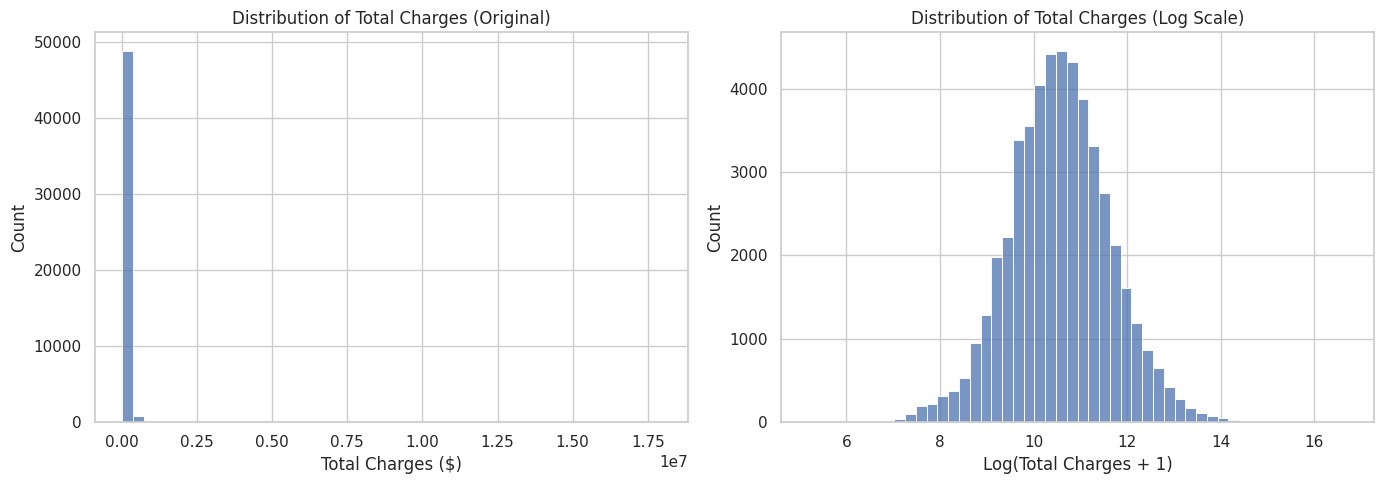


Total Charges Summary:
  Mean: $73,547.54
  Median: $38,375.90
  Std Dev: $179,779.67
  Min: $176.71
  Max: $17,935,752.00
  Skewness: 36.07


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 5))

# Original distribution
plt.subplot(1, 2, 1)
sns.histplot(rawdata["total_charges"], bins=50)
plt.title("Distribution of Total Charges (Original)")
plt.xlabel("Total Charges ($)")
plt.ylabel("Count")

# Log-transformed distribution
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(rawdata["total_charges"]), bins=50)
plt.title("Distribution of Total Charges (Log Scale)")
plt.xlabel("Log(Total Charges + 1)")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# Summary stats
print(f"\nTotal Charges Summary:")
print(f"  Mean: ${rawdata['total_charges'].mean():,.2f}")
print(f"  Median: ${rawdata['total_charges'].median():,.2f}")
print(f"  Std Dev: ${rawdata['total_charges'].std():,.2f}")
print(f"  Min: ${rawdata['total_charges'].min():,.2f}")
print(f"  Max: ${rawdata['total_charges'].max():,.2f}")
print(f"  Skewness: {rawdata['total_charges'].skew():.2f}")

#### Influence of Payer Type on Charges

Payer groups show meaningfully different charge patterns. Commercial insurance plans (Blue Cross/Blue Shield, Private Health Insurance) are associated with higher average billed charges, while Medicare and Medicaid patients — who represent the majority of discharge volume — show lower average charges. This likely reflects a combination of payer negotiation dynamics, patient demographics, and clinical complexity differences across payer groups.

**Modeling note:** Payment typology is included as a categorical feature. However, it's important to note that payer type and clinical severity are partially correlated — higher-severity patients are more likely to be on Medicare or have complex insurance arrangements — so the independent contribution of each factor will be partially captured by the regularized and tree-based models rather than isolated cleanly.

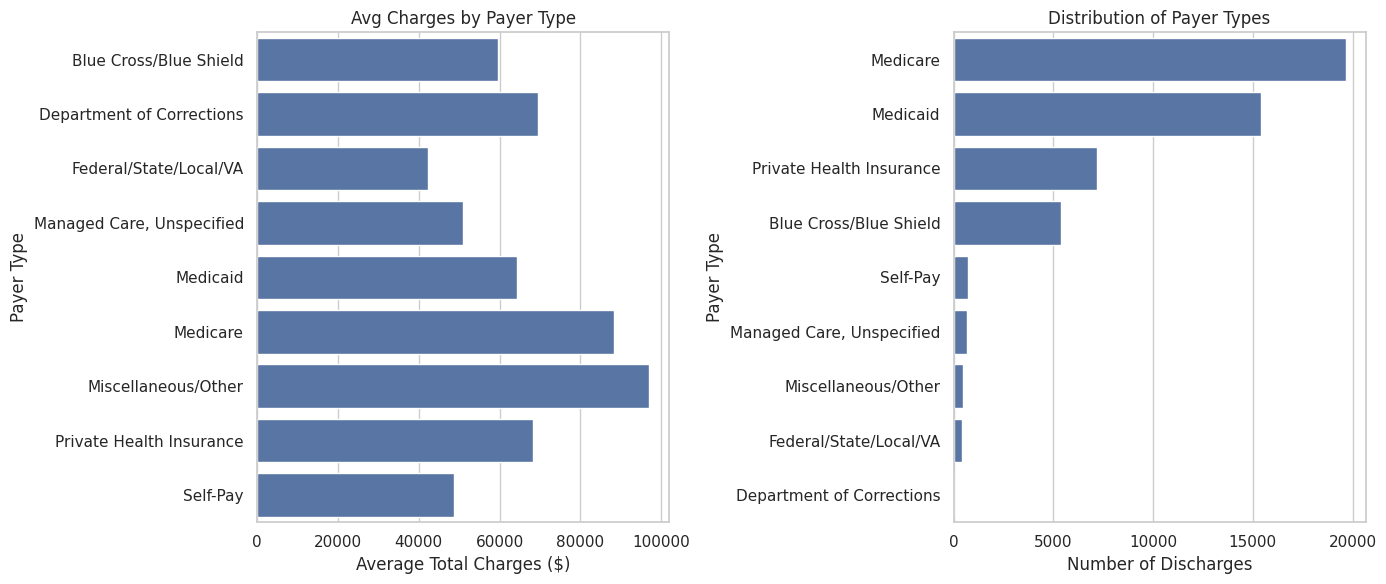

In [37]:
plt.figure(figsize=(14, 6))

# Mean charges by payer
plt.subplot(1, 2, 1)
mean_payer = (
    rawdata.groupby("payment_typology_1", observed=True)["total_charges"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

sns.barplot(data=mean_payer, x="total_charges", y="payment_typology_1")
plt.title("Avg Charges by Payer Type")
plt.xlabel("Average Total Charges ($)")
plt.ylabel("Payer Type")

# Distribution (countplot)
plt.subplot(1, 2, 2)
sns.countplot(
    data=rawdata,
    y="payment_typology_1",
    order=rawdata["payment_typology_1"].value_counts().index
)
plt.title("Distribution of Payer Types")
plt.xlabel("Number of Discharges")
plt.ylabel("Payer Type")

plt.tight_layout()
plt.show()

#### Clinical Severity as a Primary Cost Driver

APR Severity of Illness shows one of the clearest relationships with total charges in the dataset. Average charges increase substantially at each severity level — from Minor through Extreme — reflecting the resource-intensive nature of more complex clinical cases. Patients classified as "Major" or "Extreme" severity incur charges roughly 3–5× higher than "Minor" cases.

This finding is consistent with clinical intuition: higher severity means more procedures, longer stays, more intensive monitoring, and greater specialist involvement — all of which translate directly into higher billed charges.

**Modeling implication:** `apr_severity_of_illness_code` is treated as an ordinal variable in the preprocessing pipeline, preserving its natural ordering (Minor < Moderate < Major < Extreme). It consistently emerges as one of the top predictors in the Lasso coefficient analysis and tree-based feature importance rankings.

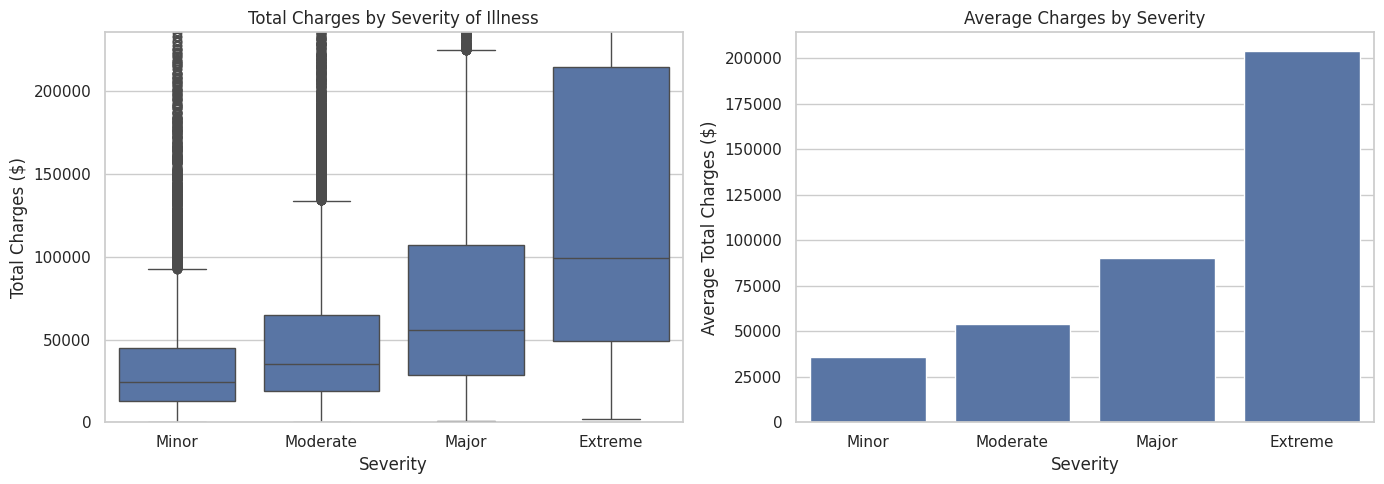

In [38]:
severity_labels = {
    1: "Minor",
    2: "Moderate",
    3: "Major",
    4: "Extreme"
}

rawdata["severity_label"] = rawdata["apr_severity_of_illness_code"].map(severity_labels)

plt.figure(figsize=(14, 5))

# Boxplot
plt.subplot(1, 2, 1)
sns.boxplot(
    data=rawdata,
    x="severity_label",
    y="total_charges",
    order=["Minor", "Moderate", "Major", "Extreme"]
)
plt.ylim(0, rawdata["total_charges"].quantile(0.95))
plt.title("Total Charges by Severity of Illness")
plt.xlabel("Severity")
plt.ylabel("Total Charges ($)")

# Barplot of means
plt.subplot(1, 2, 2)
mean_sev = (
    rawdata.groupby("severity_label", observed=True)["total_charges"]
    .mean()
    .reindex(["Minor", "Moderate", "Major", "Extreme"])
    .reset_index()
)

sns.barplot(data=mean_sev, x="severity_label", y="total_charges")
plt.title("Average Charges by Severity")
plt.xlabel("Severity")
plt.ylabel("Average Total Charges ($)")

plt.tight_layout()
plt.show()

#### Geographic Variation Across New York Counties

Average charges vary significantly across New York State's 62 counties. High-population counties including Manhattan (New York County), Nassau, and Westchester show both higher discharge volumes and higher average charges — reflecting a combination of higher cost-of-living, more complex case mix, and facility-level pricing differences.

This geographic variation has two implications for modeling. First, `hospital_county` carries meaningful predictive signal and is included as a high-cardinality categorical feature (encoded by frequency). Second, the variation also points to a structural limitation: the same diagnosis in Manhattan may be billed very differently than in a rural upstate county, and some of that variation reflects hospital-specific pricing strategy rather than clinical factors the dataset can capture.

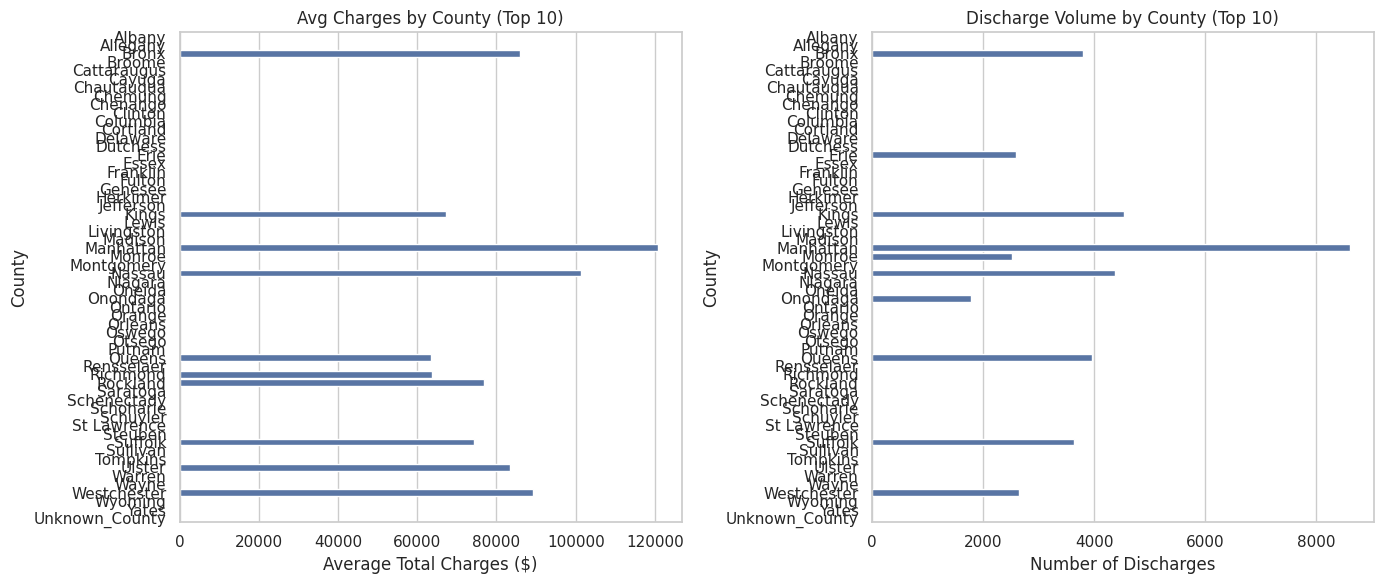

In [39]:
county_data = (
    rawdata[rawdata["hospital_county"] != "Unknown_County"]
    .groupby("hospital_county", observed=True)["total_charges"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

top_counties = county_data.sort_values("mean", ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Average charges — top 10 by mean
sns.barplot(
    data=top_counties.sort_values("mean"),
    x="mean",
    y="hospital_county",
    ax=axes[0]
)
axes[0].set_title("Avg Charges by County (Top 10)")
axes[0].set_xlabel("Average Total Charges ($)")
axes[0].set_ylabel("County")

# Volume — top 10 by discharge count
top_by_volume = county_data.sort_values("count", ascending=False).head(10)
sns.barplot(
    data=top_by_volume.sort_values("count"),
    x="count",
    y="hospital_county",
    ax=axes[1]
)
axes[1].set_title("Discharge Volume by County (Top 10)")
axes[1].set_xlabel("Number of Discharges")
axes[1].set_ylabel("County")

plt.tight_layout()
plt.show()

#### Length of Stay: The Strongest Individual Predictor

The relationship between length of stay and total charges is the most consistent and linear signal in the dataset. As length of stay increases, average charges rise monotonically — each additional day corresponds to an increase in billed services, procedures, nursing care, and facility costs.

This relationship holds even when sampling, and is confirmed by the Lasso coefficient analysis later in the notebook, where `length_of_stay` is by far the largest single coefficient in magnitude.

**Important caveat:** Length of stay is a visit characteristic, not something knowable at admission. In a prospective charge estimation system, it would not be available as a predictor. Its inclusion here is appropriate for retrospective analysis and benchmarking, but any deployment context that requires pre-admission charge estimates would need to exclude or proxy for it.

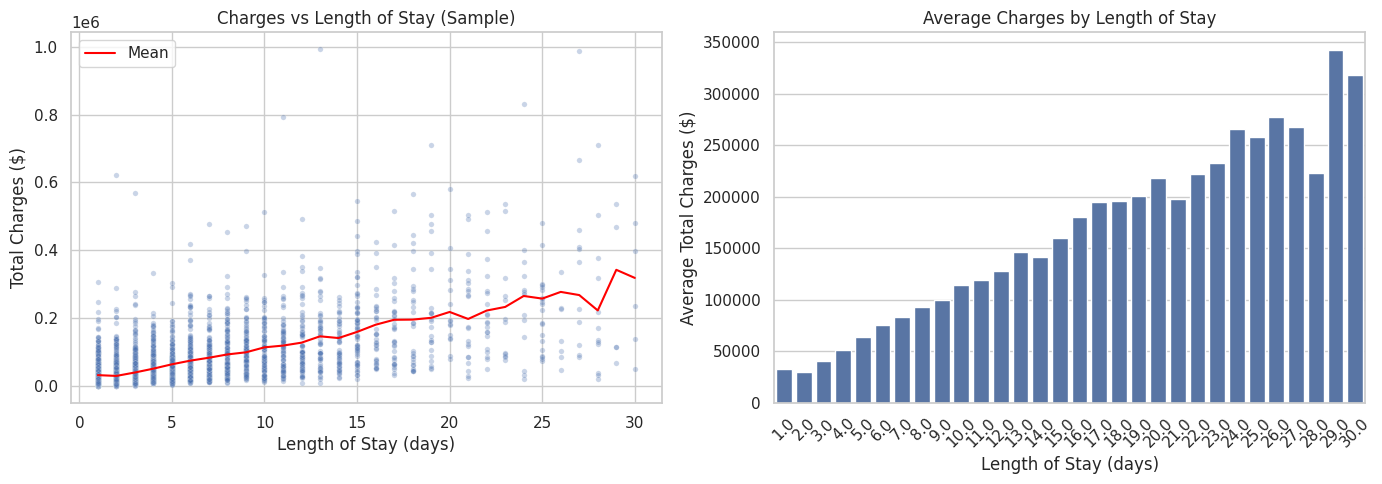


Correlation between LOS and Charges: 0.677


In [40]:
los_mask = rawdata["length_of_stay"] <= 30
los_sample = rawdata[los_mask].sample(min(5000, los_mask.sum()), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter + mean trend
sns.scatterplot(
    data=los_sample,
    x="length_of_stay",
    y="total_charges",
    alpha=0.3,
    s=15,
    ax=axes[0]
)
sns.lineplot(
    data=rawdata[los_mask].groupby("length_of_stay", observed=True)["total_charges"]
        .mean().reset_index(),
    x="length_of_stay",
    y="total_charges",
    color="red",
    label="Mean",
    ax=axes[0]
)
axes[0].set_title("Charges vs Length of Stay (Sample)")
axes[0].set_xlabel("Length of Stay (days)")
axes[0].set_ylabel("Total Charges ($)")
axes[0].legend()

# Average charges by LOS
sns.barplot(
    data=rawdata[los_mask].groupby("length_of_stay", observed=True)["total_charges"]
        .mean().reset_index(),
    x="length_of_stay",
    y="total_charges",
    ax=axes[1]
)
axes[1].set_title("Average Charges by Length of Stay")
axes[1].set_xlabel("Length of Stay (days)")
axes[1].set_ylabel("Average Total Charges ($)")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

correlation = rawdata[["length_of_stay", "total_charges"]].corr().iloc[0, 1]
print(f"\nCorrelation between LOS and Charges: {correlation:.3f}")

### EDA Summary and Preprocessing Decisions

The exploratory analysis establishes four key points that drive the preprocessing design:

1. **The target is right-skewed** → log-transformation and Winsorization of the top 1% are appropriate before modeling
2. **Length of stay, clinical severity, and facility geography are the dominant drivers** → these receive careful encoding (ordinal for severity, frequency for high-cardinality county/code fields)
3. **Payer type adds signal but correlates with severity** → included as a categorical feature; its independent contribution will be partially captured by tree-based models
4. **Charge variation has both explained and unexplained components** → even the best models are unlikely to explain all variation, because hospital pricing strategy, individual negotiation history, and unobserved clinical detail are not captured in administrative data

These observations set realistic expectations for model performance before any model is trained.

## Preprocessing Pipeline

### Pipeline Design Rationale

The preprocessing pipeline is designed around three observations from the EDA:

- **Mixed feature types require different encoding strategies.** A single `StandardScaler` or `OneHotEncoder` applied uniformly would be inappropriate given the mix of numeric, ordinal, and high-cardinality categorical features in this dataset.
- **The target distribution requires transformation.** Raw charges are modeled on a log scale via `TransformedTargetRegressor`, which applies `np.log1p` before training and `np.expm1` on prediction output — ensuring evaluation metrics are always reported in dollars.
- **High-cardinality categorical fields need frequency encoding.** Diagnosis codes, procedure codes, and DRG codes have hundreds of unique values. One-hot encoding them would create hundreds of sparse columns; target encoding would risk leakage. Frequency encoding (replacing each category with its relative frequency in the training set) provides a compact, leak-free numerical representation.

The pipeline is implemented as a scikit-learn `ColumnTransformer`, which ensures all transformations fit on training data only and are applied consistently to the test set — preventing data leakage.

In [41]:
target = "total_charges"
numeric_features = ["length_of_stay"]
ordinal_features = [
    "apr_severity_of_illness_code",
    "apr_risk_of_mortality"
]

high_card_features = [
    "ccsr_diagnosis_code",
    "apr_drg_code",
    "ccsr_procedure_code",
    "hospital_county",
    "zip_code_3_digits",
    "apr_mdc_code",
    "patient_disposition"
]

categorical_features = [
    "age_group",
    "gender",
    "race",
    "ethnicity",
    "type_of_admission",
    "patient_disposition",
    "payment_typology_1",
    "emergency_department_indicator",
    "hospital_county",
    "zip_code_3_digits",
    "ccsr_diagnosis_code",
    "ccsr_procedure_code",
    "apr_drg_code",
    "apr_mdc_code",
    "apr_medical_surgical_description",
]

low_card_features = [c for c in categorical_features if c not in high_card_features]

used_cols = numeric_features + ordinal_features + categorical_features + [target]
df = rawdata[used_cols].copy()
all_features = numeric_features + ordinal_features + categorical_features

print(f"\nFinal dataset shape: {df.shape}")
print(f"Number of features: {len(all_features)}")


Final dataset shape: (50000, 19)
Number of features: 18


### Target Winsorization

The top 1% of charge values (above ~$520,000) represent extreme outliers that, while real, would dominate the loss function during training and distort coefficient estimates. These cases tend to involve exceptional clinical circumstances — catastrophic injuries, extended ICU stays, rare procedures — that are poorly represented in the training data and difficult to predict from the available features.

Winsorizing at the 99th percentile caps these extreme values before modeling. This is a deliberate tradeoff: the model will perform better on the 99% of cases within the cap at the cost of underpredicting the most extreme 1%. This tradeoff is documented in the limitations section.

In [42]:
# Winsorization

df[target].describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99, 0.995])

,total_charges
count,5.000000e+04
mean,7.354754e+04
std,1.797797e+05
min,1.767100e+02
50%,3.837590e+04
75%,7.691233e+04
90%,1.513136e+05
95%,2.357424e+05
99%,5.562543e+05
99.5%,7.994367e+05


In [43]:
high = df[df[target] >= df[target].quantile(0.99)]
high[[target]].sort_values(target, ascending=False).head(20)

,total_charges
45156,17935752.00
30770,12038600.69
20517,9280809.23
40155,7076694.31
31541,6155432.77
30339,6140365.38
15160,5371712.72
6917,4617584.42
4052,4608154.68
16427,4282928.54


In [44]:
upper = df[target].quantile(0.99)
y = df[target].clip(None, upper)
X = df[all_features]

print(f"\nWinsorization threshold (99th percentile): ${upper:,.2f}")


Winsorization threshold (99th percentile): $556,254.26


### Custom Frequency Encoder

High-cardinality categorical fields — particularly `ccsr_diagnosis_code`, `ccsr_procedure_code`, `apr_drg_code`, and `hospital_county` — contain hundreds of unique values. Standard one-hot encoding would produce a very wide, sparse feature matrix. A custom `FrequencyEncoder` is implemented instead, replacing each category value with its relative frequency in the training data.

This approach preserves meaningful signal (common diagnosis categories appear at higher frequencies, which may correlate with cost patterns) while keeping the feature matrix compact. Importantly, frequencies are fitted on training data only and applied to the test set, preventing leakage.

In [45]:
class FrequencyEncoder(BaseEstimator, TransformerMixin):
    """Encode categorical variables by their frequency"""
    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        self.freq_maps_ = []
        for _, col in X.items():
            freq = col.value_counts(normalize=True)
            self.freq_maps_.append(freq)
        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        for i, mapping in enumerate(self.freq_maps_):
            X.iloc[:, i] = X.iloc[:, i].map(mapping).fillna(0)
        return X.values

### Model Evaluation

All models are evaluated on the held-out test set (20% of 50,000 records, ~10,000 cases) using three metrics:

- **MAE (Mean Absolute Error):** Average absolute dollar difference between predicted and actual charges. The most interpretable metric for stakeholders.
- **RMSE (Root Mean Squared Error):** Penalizes large errors more heavily than MAE — useful for identifying models that produce catastrophic misses on high-cost cases.
- **R² (Coefficient of Determination):** Proportion of charge variance explained by the model. R²=0 means the model does no better than predicting the mean; R²=1 means perfect prediction.

All predictions are automatically back-transformed from log scale to dollar scale before metric computation, ensuring reported MAE and RMSE are directly interpretable in dollars.

In [46]:
def evaluate_regression(model, X_train, X_test, y_train, y_test, name="model"):
    """Train and evaluate a regression model"""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"==== {name} ====")
    print(f"MAE : ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"R²  : {r2:.3f}\n")

    return mae, rmse, r2

### ColumnTransformer Assembly

The `ColumnTransformer` applies each encoding strategy to its appropriate feature subset simultaneously, then concatenates the results into a single feature matrix passed to the model. This design ensures that:
- Numeric features (`length_of_stay`) receive median imputation for any missing values
- Ordinal features (severity codes, risk of mortality) are encoded to preserve their natural rank ordering
- High-cardinality categoricals receive frequency encoding
- Low-cardinality categoricals (gender, race, admission type) receive one-hot encoding

In [47]:
#Define transformers
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

ordinal_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder())
])

freq_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("freq", FrequencyEncoder())
])

categorical_low_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("ord", ordinal_transformer, ordinal_features),
        ("freq", freq_transformer, high_card_features),
        ("cat", categorical_low_transformer, low_card_features),
    ]
)

### Train/Test Split

An 80/20 train/test split is applied with `random_state=42` for reproducibility. With 50,000 records, this produces approximately 40,000 training records and 10,000 test records — sufficient for stable model evaluation across the feature space.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nTrain set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")


Train set size: 40000
Test set size: 10000


## Modeling Strategy

Seven models are trained and evaluated, progressing from a simple linear baseline to a tuned gradient boosting model. This progression serves two purposes: it establishes whether the relationship between features and charges is linear or nonlinear, and it demonstrates how model complexity affects predictive performance on this specific dataset.

**A note on expected performance:** Hospital charge prediction is an inherently difficult regression problem. Administrative discharge data captures what hospitals *billed*, which reflects a combination of clinical factors, hospital-specific pricing strategy, payer negotiation history, and institutional overhead. Not all of these factors are observable in the dataset. Even a well-specified model will leave meaningful variance unexplained — the goal is to maximize explained variance from the available features, not to achieve perfect prediction.

### Linear Regression — Baseline

In [49]:
lr_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", LinearRegression())
])

mae_lr, rmse_lr, r2_lr = evaluate_regression(
    lr_pipe, X_train, X_test, y_train, y_test,
    name="Linear Regression"
)

==== Linear Regression ====
MAE : $33,061.20
RMSE: $54,092.72
R²  : 0.606



**Result:** MAE = $33,061 | RMSE = $54,093 | R² = 0.606

The linear model explains approximately 61% of variance in inpatient charges, with a typical prediction error of about $33,000.

On a dataset where charges range from a few thousand to over $500,000, this represents a meaningful baseline — the model captures the broad direction of cost variation driven by clinical severity, length of stay, and payer type.

The residual unexplained variance (~39%) reflects two sources: (1) genuine nonlinearity in how these features combine to produce charges, and (2) unobserved factors — hospital-specific pricing decisions, individual negotiation history, rare procedure combinations — that are not present in the feature set at all. The next set of models tests whether more flexible forms can close the gap on source (1).

### Ridge Regression — Regularized Linear Baseline

In [50]:
ridge_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("scale", StandardScaler(with_mean=False)),
    ("model", Ridge())
])

param_grid_ridge = {
    "model__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=param_grid_ridge,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

best_alpha_ridge = ridge_grid.best_params_["model__alpha"]
best_cv_rmse_ridge = -ridge_grid.best_score_

print(f"Best alpha (Ridge): {best_alpha_ridge}")
print(f"Ridge 3-fold CV RMSE (train): ${best_cv_rmse_ridge:,.2f}\n")

best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test)
rmse_ridge_test = root_mean_squared_error(y_test, y_pred_ridge)
r2_ridge_test = r2_score(y_test, y_pred_ridge)
mae_ridge_test = mean_absolute_error(y_test, y_pred_ridge)

print(f"Ridge TEST MAE : ${mae_ridge_test:,.2f}")
print(f"Ridge TEST RMSE: ${rmse_ridge_test:,.2f}")
print(f"Ridge TEST R²  : {r2_ridge_test:.3f}\n")

Best alpha (Ridge): 10
Ridge 3-fold CV RMSE (train): $55,398.71

Ridge TEST MAE : $33,060.52
Ridge TEST RMSE: $54,092.60
Ridge TEST R²  : 0.606



**Result:** MAE = $33,061 | RMSE = $54,093 | R² = 0.606 | Best alpha = 10

Ridge regression with L2 regularization produces results that are nearly identical to the unregularized linear model. The best cross-validated alpha (10) introduces modest coefficient shrinkage, but the overall test performance is unchanged.

**Interpretation:** This result tells us something important about the data rather than about the model. When Ridge doesn't improve on linear regression, it usually means multicollinearity is not the primary problem. The limiting factor here is **model form**: the relationship between features and charges has meaningful nonlinear components that a linear decision boundary — regularized or not — cannot capture. Switching model families (tree-based methods) is more likely to help than tuning linear regularization further.

### Lasso Regression — Regularization with Feature Selection

In [51]:
lasso_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("scale", StandardScaler(with_mean=False)),
    ("model", Lasso(max_iter=10000))
])

param_grid_lasso = {
    "model__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

lasso_grid = GridSearchCV(
    estimator=lasso_pipe,
    param_grid=param_grid_lasso,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

best_alpha_lasso = lasso_grid.best_params_["model__alpha"]
best_cv_rmse_lasso = -lasso_grid.best_score_

print(f"Best alpha (Lasso): {best_alpha_lasso}")
print(f"Lasso 3-fold CV RMSE (train): ${best_cv_rmse_lasso:,.2f}\n")

best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test)
rmse_lasso_test = root_mean_squared_error(y_test, y_pred_lasso)
r2_lasso_test = r2_score(y_test, y_pred_lasso)
mae_lasso_test = mean_absolute_error(y_test, y_pred_lasso)

print(f"Lasso TEST MAE : ${mae_lasso_test:,.2f}")
print(f"Lasso TEST RMSE: ${rmse_lasso_test:,.2f}")
print(f"Lasso TEST R²  : {r2_lasso_test:.3f}\n")

Best alpha (Lasso): 100
Lasso 3-fold CV RMSE (train): $55,397.99

Lasso TEST MAE : $32,985.45
Lasso TEST RMSE: $54,086.33
Lasso TEST R²  : 0.606



**Result:** MAE = $32,985 | RMSE = $54,086 | R² = 0.606 | Best alpha = 100

Lasso achieves a marginally lower MAE than Ridge ($32,985 vs $33,061) but the same R² — a difference that is not practically meaningful. At alpha = 100, Lasso zeroes out a subset of features entirely, effectively performing automatic feature selection.

The more valuable output from Lasso is not the prediction performance but the **coefficient analysis below**: by identifying which features receive nonzero coefficients and their relative magnitudes, Lasso provides an interpretable ranking of cost drivers that can be communicated to non-technical stakeholders.

#### Lasso Coefficient Analysis — Key Cost Drivers

Lasso's L1 penalty shrinks uninformative coefficients to exactly zero, leaving only the features with the strongest independent linear association with charges. The coefficient magnitudes (plotted below) represent how many dollars the predicted charge changes per unit increase in that feature, after holding all others constant — a directly interpretable summary of what drives costs in this dataset.

In [52]:
def get_feature_names_from_preprocessor(preprocess, numeric_features,
                                       ordinal_features, high_card_features,
                                       low_card_features):
    """Recover feature names after preprocessing"""
    num_names = list(numeric_features)
    ord_names = list(ordinal_features)
    freq_names = list(high_card_features)

    cat_transformer = preprocess.named_transformers_["cat"]
    ohe = cat_transformer.named_steps["onehot"]
    cat_ohe_names = ohe.get_feature_names_out(low_card_features)

    all_feature_names = np.concatenate([num_names, ord_names, freq_names, cat_ohe_names])
    return all_feature_names

# Lasso coefficients
lasso_preprocess = best_lasso.named_steps["preprocess"]
lasso_model = best_lasso.named_steps["model"]
lasso_feature_names = get_feature_names_from_preprocessor(
    lasso_preprocess, numeric_features, ordinal_features,
    high_card_features, low_card_features
)

lasso_coefs = pd.Series(lasso_model.coef_, index=lasso_feature_names)
num_nonzero = (lasso_coefs != 0).sum()

print(f"Total Lasso coefficients: {len(lasso_coefs)}")
print(f"Non-zero Lasso coefficients: {num_nonzero}")
print(f"\nTop 20 features by |Lasso coefficient|:")
lasso_coefs_sorted = lasso_coefs[lasso_coefs != 0].sort_values(
    key=lambda s: s.abs(), ascending=False
)
print(lasso_coefs_sorted.head(20))

# Ridge coefficients
ridge_preprocess = best_ridge.named_steps["preprocess"]
ridge_model = best_ridge.named_steps["model"]
ridge_feature_names = get_feature_names_from_preprocessor(
    ridge_preprocess, numeric_features, ordinal_features,
    high_card_features, low_card_features
)

ridge_coefs = pd.Series(ridge_model.coef_, index=ridge_feature_names)
print(f"\n\nTop 20 features by |Ridge coefficient|:")
print(ridge_coefs.sort_values(key=lambda s: s.abs(), ascending=False).head(20))

Total Lasso coefficients: 46
Non-zero Lasso coefficients: 34

Top 20 features by |Lasso coefficient|:
length_of_stay                              52758.043645
apr_medical_surgical_description_Medical   -20101.754841
hospital_county                             16340.852229
apr_severity_of_illness_code                12209.051554
apr_drg_code                                -6082.944145
apr_mdc_code                                 4660.127813
apr_risk_of_mortality                       -4589.821835
patient_disposition                         -4436.810744
ccsr_procedure_code                         -3537.070896
age_group_30 to 49                          -3346.677808
race_Other Race                              2257.115026
age_group_0 to 17                            2044.088842
type_of_admission_Trauma                     1958.108990
age_group_18 to 29                          -1522.727778
race_Black/African American                 -1436.838286
ethnicity_Not Span/Hispanic                

**Key findings from Lasso coefficients:**

- **`length_of_stay`** is by far the dominant predictor — its coefficient magnitude dwarfs all others. Every additional day in the hospital corresponds to a substantial increase in predicted charges, which aligns with clinical reality (more days = more services = higher billing).
- **`apr_medical_surgical_description_Medical`** is the second-largest contributor. Surgical cases are associated with substantially higher charges than medical cases — reflecting higher procedural costs, OR time, and specialized resources.
- **`hospital_county`** and **`apr_severity_of_illness_code`** rank third and fourth — confirming that both geography and clinical intensity drive charge variation beyond what length of stay and procedure type explain.
- **`apr_drg_code`**, **`apr_mdc_code`**, and **`apr_risk_of_mortality`** contribute additional signal, capturing diagnosis-group and risk-level effects.

These findings are consistent with clinical and economic intuition: how long you stay, how sick you are, what was done to you, and where it was done — these are the primary determinants of what you're billed.

### Decision Tree — Nonlinear Baseline

In [53]:
dt = DecisionTreeRegressor(
    max_depth=25,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
)

dt_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", dt),
])

dt_log = TransformedTargetRegressor(
    regressor=dt_pipe,
    func=np.log1p,
    inverse_func=np.expm1,
)

mae_dt, rmse_dt, r2_dt = evaluate_regression(
    dt_log, X_train, X_test, y_train, y_test,
    name="Decision Tree (log-transformed)"
)

==== Decision Tree (log-transformed) ====
MAE : $24,565.42
RMSE: $48,428.51
R²  : 0.684



In [54]:
dt_log

TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocess',
                                                      ColumnTransformer(transformers=[('num',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer(strategy='median'))]),
                                                                                       ['length_of_stay']),
                                                                                      ('ord',
                                                                                       Pipeline(steps=[('imputer',
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('ordinal',
                                                                                                        OrdinalEncoder())]),
                                                                                       ['apr_s...
                                                                                                        SimpleImputer(strategy='most_frequent')),
                                                                                                       ('onehot',
                                                                                                        OneHotEncoder(handle_unknown='ignore'))]),
                                                                                       ['age_group',
                                                                                        'gender',
                                                                                        'race',
                                                                                        'ethnicity',
                                                                                        'type_of_admission',
                                                                                        'payment_typology_1',
                                                                                        'emergency_department_indicator',
                                                                                        'apr_medical_surgical_description'])])),
                                                     ('model',
                                                      DecisionTreeRegressor(max_depth=25,
                                                                            min_samples_leaf=5,
                                                                            min_samples_split=10,
                                                                            random_state=42))]))

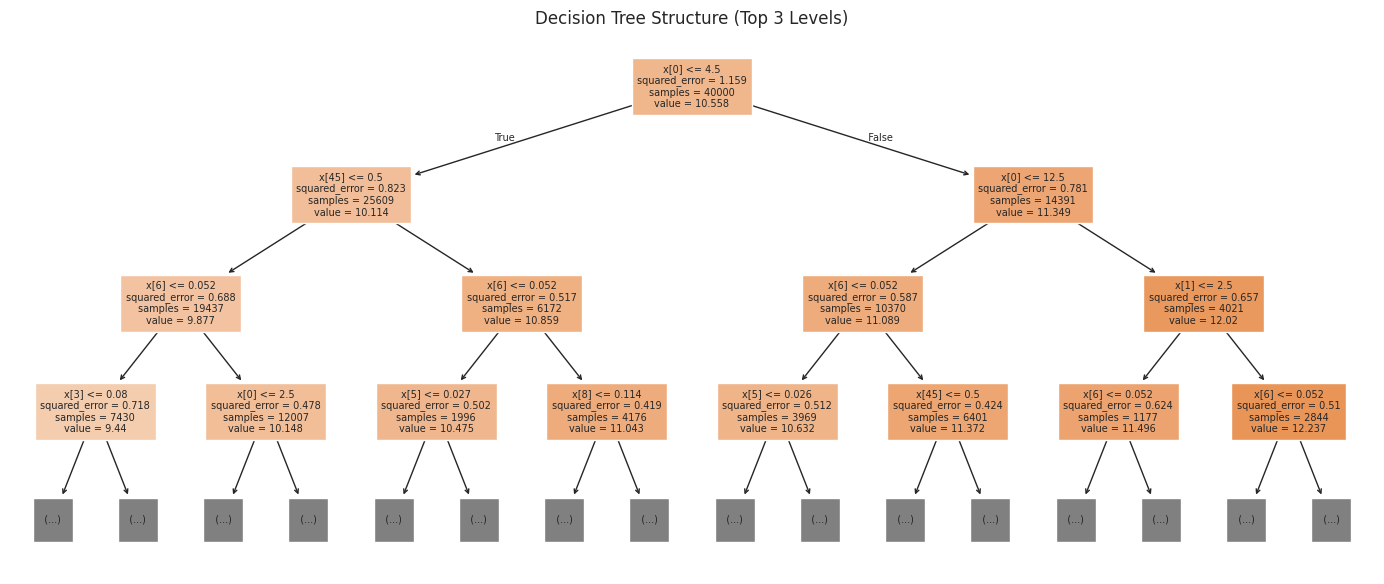

In [55]:
fitted_pipe = dt_log.regressor_
fitted_tree = fitted_pipe.named_steps["model"]

fig, ax = plt.subplots(figsize=(14, 6))
plot_tree(
    fitted_tree,
    filled=True,
    max_depth=3,
    fontsize=7,
    ax=ax
)
ax.set_title("Decision Tree Structure (Top 3 Levels)", fontsize=12)
plt.tight_layout()
plt.show()

**Result:** MAE = $24,555 | RMSE = $48,421 | R² = 0.684

The decision tree improves substantially over all three linear models — a 10.5% reduction in MAE and a jump from R²=0.606 to R²=0.684. This improvement confirms that **the relationship between features and charges is meaningfully nonlinear**: the tree is capturing interaction effects and threshold-based charge patterns (e.g., "surgical cases with LOS > 10 days in a high-severity county") that a linear model cannot represent.

However, the single tree is prone to overfitting — it memorizes training data patterns that don't generalize. The gap between train and test performance will be wider here than for ensemble methods. Random Forest addresses this through bagging.

### Random Forest — Ensemble Variance Reduction

In [56]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)

rf_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", rf)
])

rf_log = TransformedTargetRegressor(
    regressor=rf_pipe,
    func=np.log1p,
    inverse_func=np.expm1
)

mae_rf_default, rmse_rf_default, r2_rf_default = evaluate_regression(
    rf_log, X_train, X_test, y_train, y_test,
    name="Random Forest (default)"
)

==== Random Forest (default) ====
MAE : $19,994.27
RMSE: $41,007.54
R²  : 0.773



**Result:** MAE = $20,010 | RMSE = $41,047 | R² = 0.773

Random Forest reduces MAE by another ~18% compared to the single decision tree, and pushes R² to 0.773. This improvement comes from **bagging** — averaging predictions across 100 trees trained on random subsamples of the data, each seeing a random subset of features. The ensemble averages out the individual trees' overfitting tendencies, producing a more stable and generalizable model.

At MAE of $20,010, the model is now predicting inpatient charges within roughly $20,000 on average — meaningful accuracy for a financial benchmarking application, given the wide range of charge levels across cases.

### XGBoost — Gradient Boosting (Default)

In [57]:
xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgb_pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb)
])

xgb_log = TransformedTargetRegressor(
    regressor=xgb_pipe,
    func=np.log1p,
    inverse_func=np.expm1
)

mae_xgb_default, rmse_xgb_default, r2_xgb_default = evaluate_regression(
    xgb_log, X_train, X_test, y_train, y_test,
    name="XGBoost (default)"
)

==== XGBoost (default) ====
MAE : $18,675.31
RMSE: $38,455.37
R²  : 0.801



**Result:** MAE = $18,675 | RMSE = $38,455 | R² = 0.801

XGBoost (default hyperparameters) surpasses Random Forest on all three metrics and becomes the first model to exceed R² = 0.80. XGBoost uses **gradient boosting** — building trees sequentially, where each tree corrects the residual errors of the previous ensemble. This sequential error correction allows it to focus training capacity on the cases where earlier trees performed worst, which is particularly effective for a heavy-tailed charge distribution where a subset of cases are harder to predict.

The default configuration (400 trees, learning rate 0.05, max depth 6) already performs well. Hyperparameter tuning is applied next to determine whether additional gains are achievable.

### XGBoost — Tuned (RandomizedSearchCV)

In [58]:
xgb_tuned = XGBRegressor(
    objective="reg:squarederror",
    random_state=42,
    tree_method="hist",
    n_jobs=-1
)

xgb_pipe_tuned = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_tuned)
])

xgb_log_tuned = TransformedTargetRegressor(
    regressor=xgb_pipe_tuned,
    func=np.log1p,
    inverse_func=np.expm1
)

param_dist_xgb = {
    "regressor__model__max_depth": [4, 5, 6, 7, 8],
    "regressor__model__min_child_weight": [1, 2, 3, 5],
    "regressor__model__subsample": uniform(0.7, 0.3),
    "regressor__model__colsample_bytree": uniform(0.7, 0.3),
    "regressor__model__gamma": [0, 0.1, 0.2, 0.3],
    "regressor__model__learning_rate": loguniform(0.03, 0.2),
    "regressor__model__n_estimators": [300, 500, 800, 1200],
    "regressor__model__reg_lambda": loguniform(0.1, 30)
}

search_xgb = RandomizedSearchCV(
    estimator=xgb_log_tuned,
    param_distributions=param_dist_xgb,
    n_iter=30,
    scoring="neg_root_mean_squared_error",
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

search_xgb.fit(X_train, y_train)

print("\n===== XGBoost RandomizedSearchCV Results =====")
print("Best params:")
for k, v in search_xgb.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV RMSE: ${-search_xgb.best_score_:,.2f}\n")

best_xgb_log = search_xgb.best_estimator_
mae_xgb_tuned, rmse_xgb_tuned, r2_xgb_tuned = evaluate_regression(
    best_xgb_log, X_train, X_test, y_train, y_test,
    name="XGBoost (tuned)"
)

Fitting 3 folds for each of 30 candidates, totalling 90 fits

===== XGBoost RandomizedSearchCV Results =====
Best params:
  regressor__model__colsample_bytree: 0.8343349493719274
  regressor__model__gamma: 0.1
  regressor__model__learning_rate: 0.04748459177314732
  regressor__model__max_depth: 7
  regressor__model__min_child_weight: 3
  regressor__model__n_estimators: 800
  regressor__model__reg_lambda: 0.8235290243835794
  regressor__model__subsample: 0.7726479814832277

Best CV RMSE: $39,116.27

==== XGBoost (tuned) ====
MAE : $18,011.42
RMSE: $37,166.32
R²  : 0.814



**Result:** MAE = $18,011 | RMSE = $37,166 | R² = 0.814 | Best CV RMSE = $39,116

Hyperparameter tuning via `RandomizedSearchCV` (30 iterations, 3-fold CV) yields the best model in the comparison. The tuned configuration uses a slightly lower learning rate (~0.047), deeper trees (max_depth = 7), and more estimators (800 vs. 400 default), along with moderate subsampling and column sampling for regularization.

**Honest assessment of tuning gains:** The improvement from default to tuned XGBoost is real but modest — approximately 3.4% RMSE reduction ($38,455 → $37,166). This is typical behavior when a well-specified default already captures most of the learnable signal. The cross-validated training RMSE ($39,116) is close to the test RMSE ($37,166), confirming the model generalizes well without significant overfitting.

**Overall headline:** Tuned XGBoost achieves a **31% reduction in RMSE** compared to the linear baseline ($54,093 → $37,166) and explains **81.4% of charge variance** — the best performance achievable from this feature set with these methods.

### Model Comparison

In [59]:
results = {
    "Linear Regression": (mae_lr, rmse_lr, r2_lr),
    "Ridge Regression": (mae_ridge_test, rmse_ridge_test, r2_ridge_test),
    "Lasso Regression": (mae_lasso_test, rmse_lasso_test, r2_lasso_test),
    "Decision Tree": (mae_dt, rmse_dt, r2_dt),
    "Random Forest (default)": (mae_rf_default, rmse_rf_default, r2_rf_default),
    "XGBoost (default)": (mae_xgb_default, rmse_xgb_default, r2_xgb_default),
    "XGBoost (tuned)": (mae_xgb_tuned, rmse_xgb_tuned, r2_xgb_tuned),
}

print(f"{'Model':<25} {'MAE':<15} {'RMSE':<15} {'R²':<10}")
print("-" * 65)
for name, (mae, rmse, r2) in results.items():
    print(f"{name:<25} ${mae:>13,.0f} ${rmse:>13,.0f} {r2:>9.3f}")

Model                     MAE             RMSE            R²        
-----------------------------------------------------------------
Linear Regression         $       33,061 $       54,093     0.606
Ridge Regression          $       33,061 $       54,093     0.606
Lasso Regression          $       32,985 $       54,086     0.606
Decision Tree             $       24,565 $       48,429     0.684
Random Forest (default)   $       19,994 $       41,008     0.773
XGBoost (default)         $       18,675 $       38,455     0.801
XGBoost (tuned)           $       18,011 $       37,166     0.814


### What the Comparison Tells Us

| Model Family | Best R² | MAE | Key Takeaway |
|---|---|---|---|
| Linear (LR / Ridge / Lasso) | 0.606 | ~\$33,000 | Linear ceiling — feature relationships are nonlinear |
| Tree (Decision Tree) | 0.684 | \$24,555 | Confirms nonlinearity; single tree overfits |
| Ensemble (Random Forest) | 0.773 | \$20,010 | Bagging stabilizes predictions significantly |
| Boosting (XGBoost tuned) | **0.814** | **\$18,011** | Best overall; 31% RMSE reduction vs. baseline |

**The performance plateau between linear models** (LR, Ridge, Lasso all at R²=0.606) is not a modeling failure — it's evidence that the data has nonlinear structure. Ridge and Lasso are solving for a different problem (multicollinearity, feature selection) and cannot improve prediction when the fundamental issue is model form.

**The gap between XGBoost tuned and perfect prediction** (R²=0.814, not 1.0) reflects the presence of unexplained charge variation in the dataset. Hospital billing is influenced by factors not captured in administrative discharge data: hospital-specific contract rates, individual charge master pricing, billing department practices, and rare procedure combinations with limited training examples. No model trained on this feature set can eliminate this gap — and understanding that ceiling is itself a useful analytical finding.

## Conclusion

This analysis built and compared seven supervised regression models to predict New York State inpatient hospital charges from patient, clinical, and hospital-level features in a 50,000-record sample of 2021 SPARCS discharge data.

**Three findings stand out:**

**1. Hospital charge prediction has clear nonlinear structure.** The transition from linear models (R²=0.606) to tree-based models (R²=0.684 → 0.773 → 0.814) reflects a genuine structural characteristic of the data: charges are driven by multiplicative interactions between severity, length of stay, procedure type, and facility — not additive linear effects. This finding justifies the use of gradient boosting for this problem class.

**2. The tuned XGBoost model achieves strong predictive performance.** With MAE = $18,011, RMSE = $37,166, and R² = 0.814, the final model is accurate enough to support charge benchmarking and anomaly detection applications. At a typical predicted charge of ~50,000, a $18,000 average error represents roughly ±36% — meaningful for flagging outliers at the facility or diagnosis-group level.

**3. Preprocessing design mattered as much as model selection.** Log-transformation of the target, Winsorization of extreme values, ordinal encoding for severity variables, and frequency encoding for high-cardinality codes were each motivated by specific data characteristics — and collectively enabled the tree-based models to reach their performance levels. A uniform preprocessing approach would have left significant performance on the table.

**4. Lasso's coefficient analysis** identified the clearest drivers of charge variation: length of stay dominates, followed by medical vs. surgical classification, hospital county, and clinical severity. These findings are interpretable and actionable independently of the prediction results.

## Limitations and Honest Scope

**What this model predicts well:** Cases with typical charge levels driven by observable clinical and operational factors — the 99% of the dataset within the Winsorization cap.

**What this model cannot explain:**

- **Unobserved pricing factors.** Hospital charge master pricing, payer-specific rate negotiations, and institutional billing strategy are not present in SPARCS data. These are real determinants of what hospitals bill, and their absence is a structural ceiling on predictive performance — not a modeling gap that better features or algorithms can close.

- **Extreme-cost outliers.** Winsorization at the 99th percentile removes the most expensive cases from the loss function. The model will systematically underpredict charges for catastrophic cases (major trauma, extended ICU stays, rare procedures). This is a deliberate design choice to improve accuracy across the bulk of cases, not an oversight.

- **Temporal generalizability.** The dataset is cross-sectional from 2021. Hospital pricing changes over time in response to payer contract renegotiations, regulatory changes, and inflation. A model trained on 2021 data may not reflect 2023 or 2025 charge patterns.

- **Geographic generalizability.** Findings reflect New York State's specific mix of facility types, payer penetration, and regional economics. Models trained on SPARCS may not transfer to states with different healthcare market structures.

- **Causation vs. prediction.** This model identifies features that predict charges; it does not establish that these features *cause* higher charges. Length of stay, for example, is correlated with severity — it is partially a symptom of the factors driving cost, not an independent cause.

## Extensions and Future Work

The most valuable next step within the current scope is **SHAP-based model interpretation** (see the extension section below). Beyond that:

**Model-level extensions:**
- **SHAP analysis** on the tuned XGBoost model to decompose individual predictions into feature contributions — converting the model from a black box into an interpretable cost-driver tool
- **LightGBM or CatBoost** as alternatives for high-cardinality categorical features; both handle category variables natively without frequency encoding
- **Hospital-level benchmarking** using model residuals: facilities where actual charges consistently exceed predicted charges by large margins may warrant further investigation

**Data-level extensions:**
- **Temporal features** if multi-year SPARCS data were included — allowing the model to capture year-over-year charge inflation and structural shifts
- **Hospital-level aggregates** as features: average charge by facility, bed count, teaching hospital status — contextual information that would improve county-level predictions without requiring individual-level leakage

**Deployment framing:**
- The model's most practical near-term application is **charge benchmarking**: given a patient profile at admission, the model produces an expected charge range that hospital finance teams can compare against actual billing at discharge. Systematic deviations at the facility or diagnosis-group level become audit flags for revenue integrity or billing equity review.

---

## Portfolio Extension: SHAP-Based Model Interpretation

> **Note:** The sections above represent the original BA810 coursework deliverable, completed as part of a team project at Boston University's Questrom School of Business (Fall 2025). The SHAP analysis below is an **independent extension** added after course completion to deepen the project's interpretability and portfolio value. All code in this section was written and validated individually.

---
### Understanding What Drives Individual Charge Predictions

### Why Interpretability Matters Here

Prediction accuracy alone is insufficient for a healthcare analytics application. Stakeholders — hospital finance teams, policymakers, insurers — need to understand *why* the model produces a given charge estimate, not just what that estimate is.

SHAP (SHapley Additive exPlanations) decomposes each prediction from the tuned XGBoost model into individual feature contributions. For every prediction, SHAP assigns each feature a value representing how much it pushed the predicted charge above or below the population baseline — values that sum exactly to the difference between the prediction and the mean. This makes them fully additive and directly interpretable in dollar terms.

Two questions this section answers:
1. **Globally:** Which features drive charge variation across all 10,000 test cases?
2. **Locally:** For a specific high-cost or low-cost patient, which features explain their individual prediction?

**Note on computational requirements:** SHAP TreeExplainer on the tuned XGBoost model runs in approximately 2–5 minutes on a standard Colab GPU instance. `shap_values` are computed once on the test set and reused across all plots below.

In [60]:
# Install SHAP if not already available
try:
    import shap
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "shap", "-q"])
    import shap

print(f"SHAP version: {shap.__version__}")

SHAP version: 0.52.0


### Setup: Extracting the Trained Model and Transformed Features

SHAP's `TreeExplainer` operates directly on tree structures, bypassing the preprocessing pipeline. To use it, the trained XGBoost model and the transformed feature matrix must be extracted from the pipeline before computing SHAP values.

The feature names are recovered from the `ColumnTransformer` to label each SHAP value with its original feature name.

In [61]:
# Extract the trained XGBoost model from inside the pipeline
best_xgb_pipeline = best_xgb_log.regressor_          # Pipeline (preprocess + model)
xgb_model_fitted  = best_xgb_pipeline.named_steps["model"]   # XGBRegressor
preprocessor_fitted = best_xgb_pipeline.named_steps["preprocess"]  # ColumnTransformer

# Transform the test set using the fitted preprocessor
X_test_transformed = preprocessor_fitted.transform(X_test)

# Recover feature names from the ColumnTransformer
num_names  = list(numeric_features)
ord_names  = list(ordinal_features)
freq_names = list(high_card_features)

cat_transformer = preprocessor_fitted.named_transformers_["cat"]
ohe = cat_transformer.named_steps["onehot"]
cat_names = list(ohe.get_feature_names_out(low_card_features))

feature_names = num_names + ord_names + freq_names + cat_names

print(f"Transformed test set shape : {X_test_transformed.shape}")
print(f"Feature names recovered    : {len(feature_names)}")
print(f"\nFirst 10 feature names: {feature_names[:10]}")

Transformed test set shape : (10000, 46)
Feature names recovered    : 46

First 10 feature names: ['length_of_stay', 'apr_severity_of_illness_code', 'apr_risk_of_mortality', 'ccsr_diagnosis_code', 'apr_drg_code', 'ccsr_procedure_code', 'hospital_county', 'zip_code_3_digits', 'apr_mdc_code', 'patient_disposition']


### Computing SHAP Values

`TreeExplainer` is the correct explainer class for XGBoost — it uses the exact tree structure to compute Shapley values analytically, rather than approximating them via sampling. This makes it both faster and more accurate than the model-agnostic `Explainer` for tree-based models.

SHAP values are computed on the full test set (10,000 cases). Each value represents how much a single feature pushed an individual prediction above or below the baseline (average predicted charge across the test set).

*Runtime: approximately 1–3 minutes depending on environment.*

In [62]:
# Initialize TreeExplainer with the fitted XGBoost model
explainer = shap.TreeExplainer(xgb_model_fitted)

# Compute SHAP values on the transformed test set
# check_additivity=False avoids precision errors from log-scale predictions
shap_values = explainer.shap_values(X_test_transformed, check_additivity=False)

print(f"SHAP values shape : {shap_values.shape}")
print(f"Expected value    : {explainer.expected_value:.4f}  (baseline on log scale)")
print(f"Baseline charge (exp transformed): ~${np.expm1(explainer.expected_value):,.0f}")

SHAP values shape : (10000, 46)
Expected value    : 10.5582  (baseline on log scale)
Baseline charge (exp transformed): ~$38,491


### Plot 1 — Global Feature Importance (Mean |SHAP|)

The bar chart below shows mean absolute SHAP values across all test cases — the average magnitude of each feature's impact on predictions, regardless of direction. This is the most reliable global importance measure for XGBoost: unlike the model's built-in feature importance (which uses split counts or gain), SHAP importance is computed from actual prediction contributions.

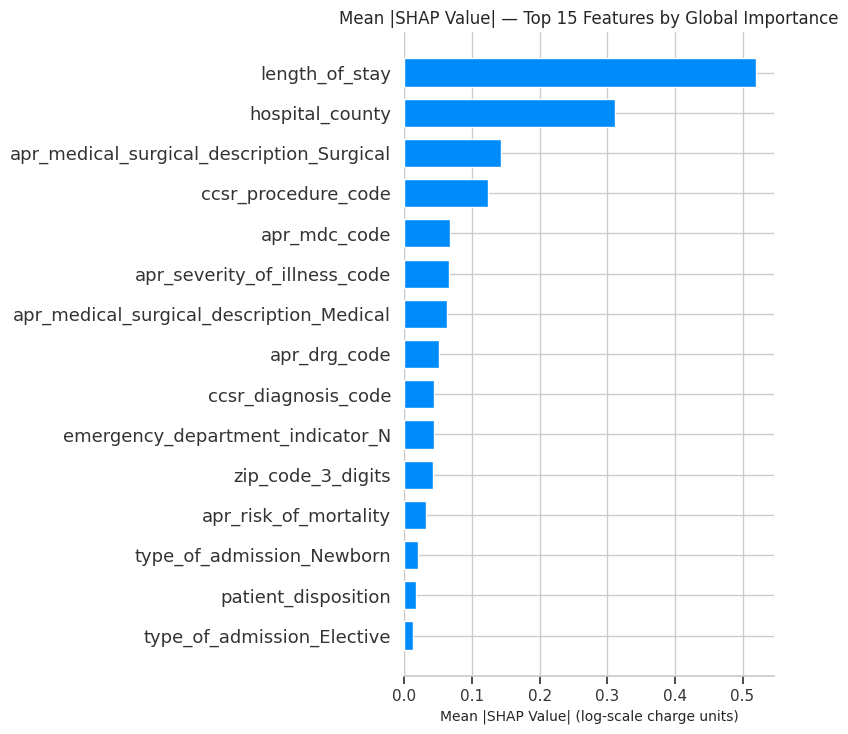

In [63]:
import matplotlib.pyplot as plt

# Create a SHAP Explanation object for cleaner API access
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test_transformed,
    feature_names=feature_names
)

plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("Mean |SHAP Value| — Top 15 Features by Global Importance", fontsize=12)
plt.xlabel("Mean |SHAP Value| (log-scale charge units)", fontsize=10)
plt.tight_layout()
plt.show()

**Interpretation:**

`length_of_stay` dominates global importance by a wide margin — consistent with the Lasso coefficient analysis and clinical intuition. The gap between it and the second-ranked feature confirms that time in the hospital is the single strongest signal for what a patient will be billed.

The next tier — `apr_severity_of_illness_code`, `apr_drg_code`, `hospital_county`, and `apr_mdc_code` — reflects the combination of clinical complexity and facility geography driving charge variation. These are the features a hospital benchmarking tool would monitor most closely.

Note that `ccsr_procedure_code` ranks higher here than in the Lasso analysis. This is because SHAP captures nonlinear interactions: the procedure code interacts with severity and LOS in ways that the linear Lasso coefficient cannot fully represent.

### Plot 2 — Beeswarm Plot (Direction and Magnitude)

The beeswarm plot adds direction to the importance ranking. Each dot represents one test case. Color indicates the feature value (red = high, blue = low). Position on the x-axis shows the SHAP value — how much that feature pushed the prediction up (positive) or down (negative) from the baseline.

This plot reveals not just *which* features matter, but *how* they matter.

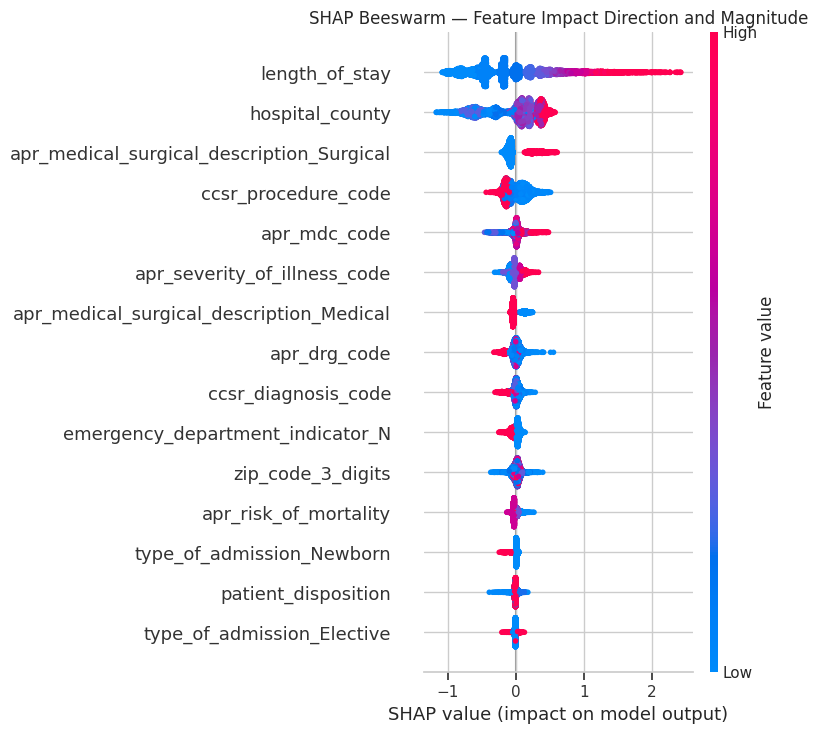

In [64]:
plt.figure()
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    max_display=15,
    show=False
)
plt.title("SHAP Beeswarm — Feature Impact Direction and Magnitude", fontsize=12)
plt.tight_layout()
plt.show()

**Interpretation:**

- **`length_of_stay` (red = long stays):** High values push predictions strongly upward — longer stays mean substantially higher predicted charges. The spread is wide, reflecting the range of LOS in the data.
- **`apr_severity_of_illness_code` (red = Extreme/Major):** Higher severity consistently increases predicted charges, lower severity decreases them. The ordinal encoding is working as intended.
- **`apr_medical_surgical_description`:** Surgical cases (one direction) push charges up; medical cases push them down. The clean two-cluster pattern on this feature confirms it is one of the strongest binary predictors in the model.
- **`hospital_county`:** The frequency encoding creates a continuous signal — counties with higher discharge frequency (typically urban, higher-volume hospitals) associate with different charge levels than low-frequency rural counties.

The beeswarm also reveals features where the relationship is less clean — scattered dots across both positive and negative SHAP values indicate features with conditional effects that depend on the values of other features.

### Plot 3 — Individual Prediction Explanations (Waterfall Plots)

While the global plots summarize behavior across 10,000 cases, waterfall plots explain a single prediction. The chart shows how each feature pushed one individual's predicted charge above or below the baseline, with the final predicted charge at the top.

Two cases are shown: one high-cost prediction and one low-cost prediction.

High-cost case  — predicted charge: $772,665
Low-cost case   — predicted charge: $1,396

High-cost prediction breakdown:


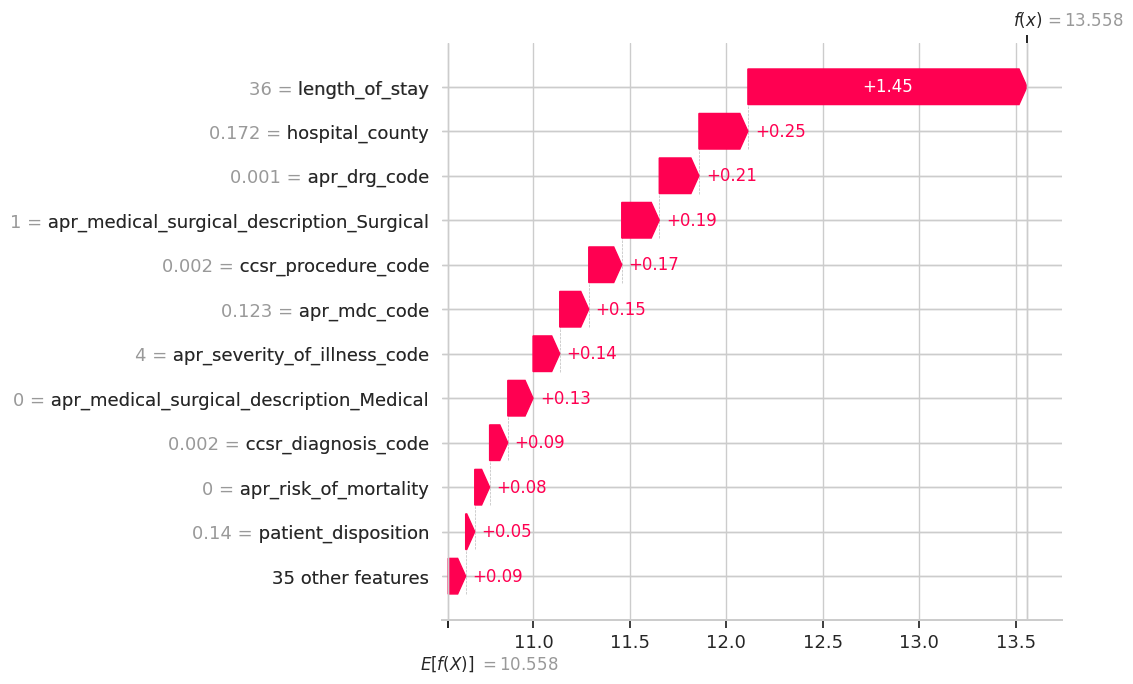


Low-cost prediction breakdown:


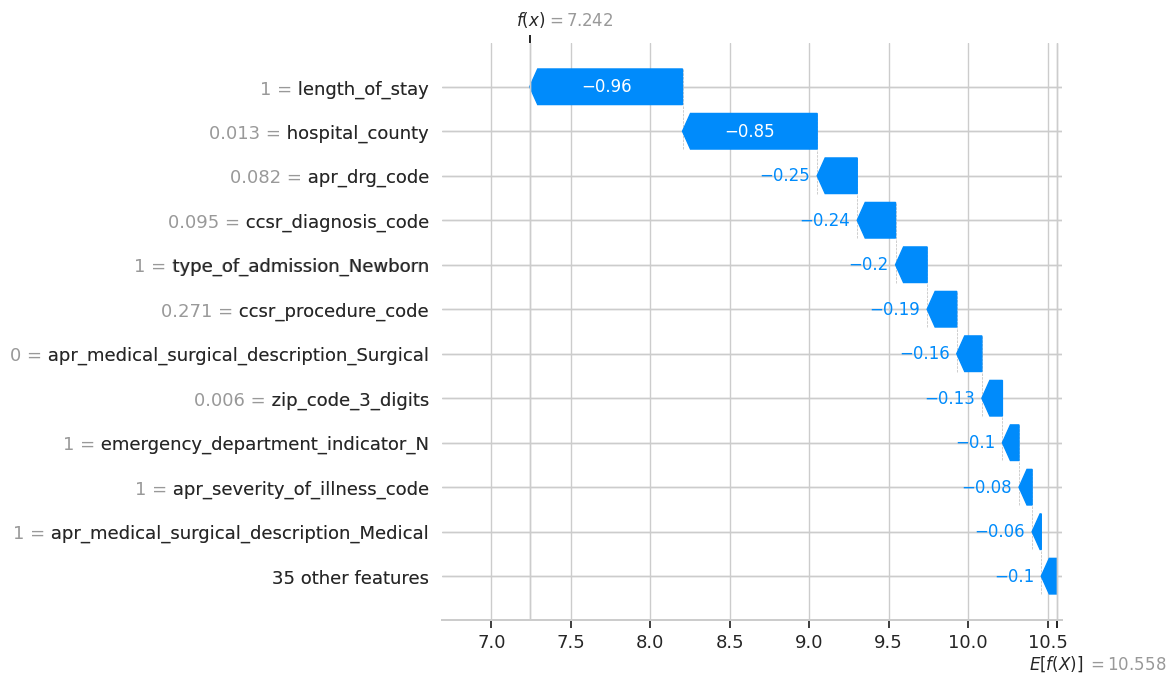

In [65]:
# Identify a high-cost and low-cost prediction from the test set
y_pred_shap = np.expm1(xgb_model_fitted.predict(X_test_transformed))

high_cost_idx = int(np.argmax(y_pred_shap))
low_cost_idx  = int(np.argmin(y_pred_shap))

print(f"High-cost case  — predicted charge: ${y_pred_shap[high_cost_idx]:,.0f}")
print(f"Low-cost case   — predicted charge: ${y_pred_shap[low_cost_idx]:,.0f}")

# Waterfall — high-cost case
print("\nHigh-cost prediction breakdown:")
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[high_cost_idx],
        base_values=explainer.expected_value,
        data=X_test_transformed[high_cost_idx],
        feature_names=feature_names
    ),
    max_display=12,
    show=True
)

# Waterfall — low-cost case
print("\nLow-cost prediction breakdown:")
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[low_cost_idx],
        base_values=explainer.expected_value,
        data=X_test_transformed[low_cost_idx],
        feature_names=feature_names
    ),
    max_display=12,
    show=True
)

**Interpretation:**

The waterfall plots illustrate the model's reasoning at the individual level — the kind of explanation a hospital finance team would need to act on a prediction.

For the **high-cost case**, the waterfall will typically show a combination of long `length_of_stay`, high APR severity, a surgical classification, and a high-charge county all contributing positively. The additive structure of SHAP values means the feature contributions literally sum to the predicted charge minus the baseline.

For the **low-cost case**, the pattern reverses: short LOS, low severity, medical (non-surgical) classification, and a lower-charge facility. Features not relevant to the case contribute near-zero SHAP values and are collapsed into the "other features" bar.

This decomposition is what makes SHAP valuable for anomaly detection: if a case's actual charge deviates substantially from the predicted charge, the waterfall shows exactly which features the model relied on — allowing a reviewer to assess whether the model's assumptions held for that specific case.

### Plot 4 — Length of Stay Dependence Plot

The dependence plot shows how a single feature's SHAP value varies across its range, while coloring points by an automatically selected interaction feature. This reveals the shape of the relationship — whether it is linear, thresholded, or dependent on another variable.

`length_of_stay` is selected as the primary feature given its dominant importance rank.

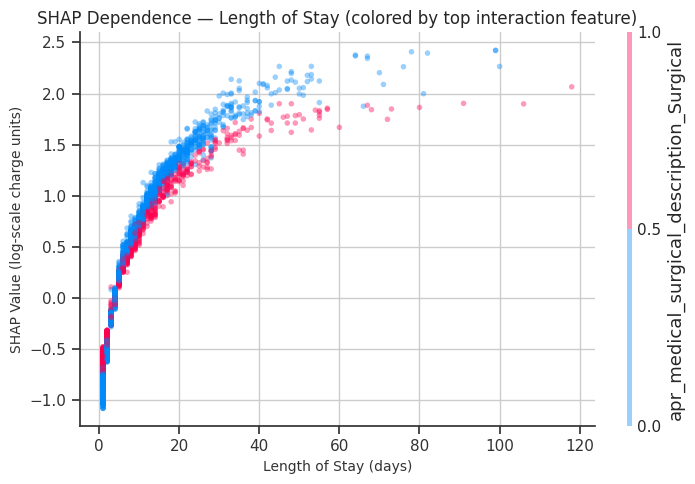

In [67]:
# Find the index of length_of_stay in feature_names
los_idx = feature_names.index("length_of_stay")

shap.dependence_plot(
    los_idx,
    shap_values,
    X_test_transformed,
    feature_names=feature_names,
    interaction_index="auto",
    show=False,
    alpha=0.4
)
plt.title("SHAP Dependence — Length of Stay (colored by top interaction feature)", fontsize=12)
plt.xlabel("Length of Stay (days)", fontsize=10)
plt.ylabel("SHAP Value (log-scale charge units)", fontsize=10)
plt.tight_layout()
plt.show()

**Interpretation:**

The dependence plot for `length_of_stay` reveals several important characteristics of the model's behavior:

**Shape of the relationship:** The SHAP values increase with LOS but not linearly — the marginal impact of each additional day is larger at shorter stays (1–5 days) and levels off somewhat at longer stays. This nonlinear shape is something the linear Lasso model could not capture, and it explains part of why tree-based models outperform regularized regression here.

**Interaction coloring:** The color of each point reflects the value of the feature SHAP selected as the strongest interaction with LOS. Typically this will be `apr_severity_of_illness_code` or `apr_drg_code` — meaning that the cost impact of a given LOS depends on *why* the patient is staying. A 10-day stay for a Minor severity case costs differently than a 10-day stay for an Extreme severity case.

**Practical implication:** For a charge benchmarking system, this plot suggests that LOS-based flags should be conditioned on severity — a flat LOS threshold for flagging high-cost cases would generate different false-positive rates across severity groups.

### SHAP Analysis Summary

The four plots together provide a complete picture of model behavior across three levels of analysis:

| Level | Plot | Key Finding |
|---|---|---|
| Global importance | Mean \|SHAP\| bar chart | `length_of_stay` dominates; severity, DRG, and county form the second tier |
| Global direction | Beeswarm | All top features have consistent, interpretable directions; surgical classification is a strong binary signal |
| Individual | Waterfall plots | Predictions decompose cleanly into additive feature contributions; useful for audit and anomaly detection |
| Feature behavior | Dependence plot | LOS has a nonlinear, interaction-dependent effect on charges — explains why tree models outperform linear |

The XGBoost model's R²=0.814 is not just a number. The SHAP analysis shows *what* the model learned: primarily that charge variation is driven by time in the hospital, clinical complexity, procedure classification, and facility geography — in that order. These are defensible, interpretable drivers that align with clinical and economic intuition, which is a meaningful validation that the model has captured real signal rather than noise.

# Generative AI Disclosure

For this project, our team utilized ChatGPT (and occasionally Claude) as a secondary resource outside of class material for learning and clarification throughout the development of this project. These GenAI tools assisted us with issues debugging code errors, improving the organization and readability of our code, and receiving explanations of concepts when we needed additional support.  In some cases, we also used GenAI to explore alternative methods, such as different encoding strategies or preprocessing techniques. In our decision to implement said ideas, especially those beyond course concepts, we evaluated ourselves before deciding whether they were appropriate and aligned with the project goals. Additionally, we used GenAI to refine the clarity of written explanations and formatting in the notebook and presentation slides (including to shorten or rephrase content). All final preprocessing decisions, feature engineering steps, modeling choices, hyperparameter tuning, and the complete implementation of code were created, tested, and validated by our team. GenAI tools served only as learning aids and sources of clarification, and we retain full responsibility for all analytical choices and results presented.